<a href="https://colab.research.google.com/github/Sarumathi-G23/Clustering-Algorithm/blob/main/Income_and_Sepnding_Analysis_using_DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [3]:
d=pd.read_csv("/content/Mall_Customers.csv")

In [4]:
d

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
d.isna().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual_Income_(k$),0
Spending_Score,0


In [6]:
d.describe

<bound method NDFrame.describe of      CustomerID   Genre  Age  Annual_Income_(k$)  Spending_Score
0             1    Male   19                  15              39
1             2    Male   21                  15              81
2             3  Female   20                  16               6
3             4  Female   23                  16              77
4             5  Female   31                  17              40
..          ...     ...  ...                 ...             ...
195         196  Female   35                 120              79
196         197  Female   45                 126              28
197         198    Male   32                 126              74
198         199    Male   32                 137              18
199         200    Male   30                 137              83

[200 rows x 5 columns]>

In [7]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    int64 
 1   Genre               200 non-null    object
 2   Age                 200 non-null    int64 
 3   Annual_Income_(k$)  200 non-null    int64 
 4   Spending_Score      200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
d['Genre']=le.fit_transform(d['Genre'])

In [9]:
from sklearn.preprocessing import StandardScaler
X = d[['Annual_Income_(k$)', 'Spending_Score']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [10]:
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=3,min_samples=4,metric='euclidean')
model=db.fit(X)#EPSILON to cluster points and avoid noise#min samples=no of features+1

In [11]:
label=model.labels_
display(label)

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1,  0,  0,  0,  0, -1, -1,  0, -1,  0, -1,  0,  0,
       -1,  0, -1, -1,  0, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  2,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  2,
        3,  3, -1,  3, -1, -1,  4, -1, -1, -1,  4,  5,  4, -1,  4,  5, -1,
        5,  4, -1,  4,  5, -1, -1,  6, -1, -1, -1,  7, -1,  6, -1,  6, -1,
        7, -1,  6, -1,  7, -1,  7, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        8, -1,  8, -1,  8, -1,  8, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [ ]:
#if labels have more -1 we need to chnage eps and min samples is that is fine tuning
#if small num of -1 we consider it as noise

In [12]:
from sklearn.cluster import DBSCAN
db_tuned = DBSCAN(eps=6, min_samples=5, metric='euclidean')
model_tuned = db_tuned.fit(X)
label_tuned = model_tuned.labels_
print("DBSCAN model re-run with adjusted parameters and new labels generated.")

DBSCAN model re-run with adjusted parameters and new labels generated.


In [13]:
display(label_tuned)

array([-1,  0, -1,  0, -1,  0, -1, -1, -1,  0, -1, -1, -1,  0, -1,  0, -1,
       -1, -1, -1, -1,  0, -1,  0, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  4, -1,  2, -1,  4,  3,  2,  3,  2, -1,  2,  3,  4,
        3,  2,  3,  2,  3,  4, -1,  4,  3,  4, -1,  2,  5,  4,  5,  4,  5,
        2,  5,  4,  3,  2,  3,  2, -1,  2,  3,  4, -1, -1,  6,  4, -1, -1,
        6, -1,  6, -1,  6, -1,  6, -1,  6, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [16]:
X = d[['Annual_Income_(k$)', 'Spending_Score']]

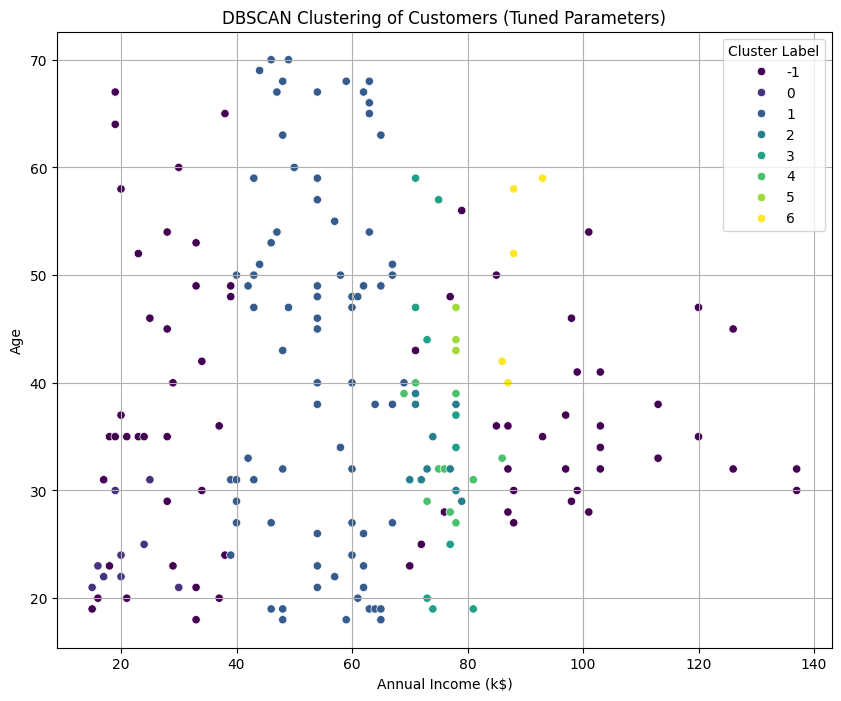

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x=d['Annual_Income_(k$)'], y=d['Age'], hue=label_tuned, palette='viridis', legend='full')
plt.title('DBSCAN Clustering of Customers (Tuned Parameters)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Age')
plt.legend(title='Cluster Label')
plt.grid(True)
plt.show()

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

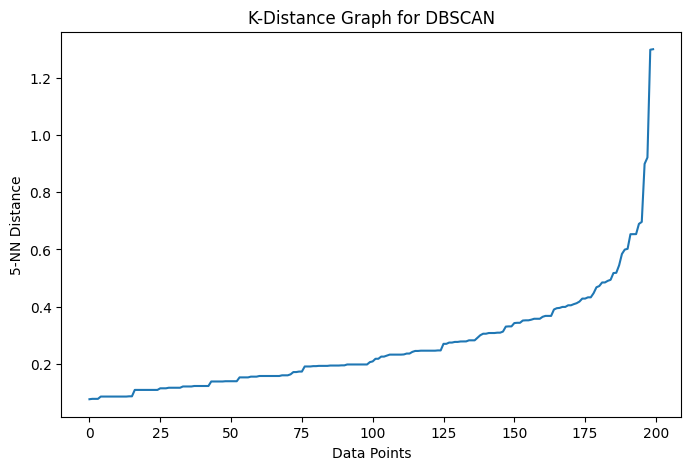

In [21]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.xlabel("Data Points")
plt.ylabel("5-NN Distance")
plt.title("K-Distance Graph for DBSCAN")
plt.show()

In [23]:
dbscan = DBSCAN(eps=0.6, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

d['Cluster'] = clusters

In [25]:
d['Cluster'].value_counts()

,count
Cluster,
0,195
-1,5


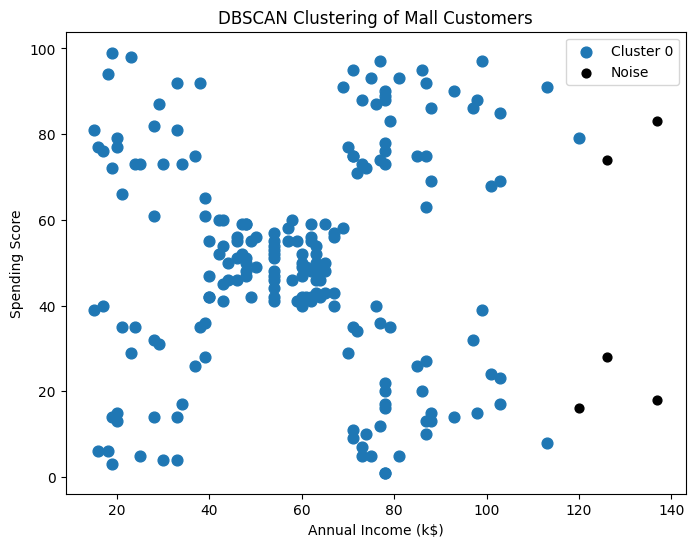

In [26]:
plt.figure(figsize=(8,6))

unique_clusters = set(clusters)

for cluster in unique_clusters:
    if cluster == -1:
        plt.scatter(
            X.iloc[clusters == cluster, 0],
            X.iloc[clusters == cluster, 1],
            c='black', label='Noise', s=40
        )
    else:
        plt.scatter(
            X.iloc[clusters == cluster, 0],
            X.iloc[clusters == cluster, 1],
            label=f'Cluster {cluster}', s=60
        )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("DBSCAN Clustering of Mall Customers")
plt.legend()
plt.show()

In [27]:
dbscan_tuned = DBSCAN(eps=0.5, min_samples=6)
clusters_tuned = dbscan_tuned.fit_predict(X_scaled)

d['Cluster_Tuned'] = clusters_tuned

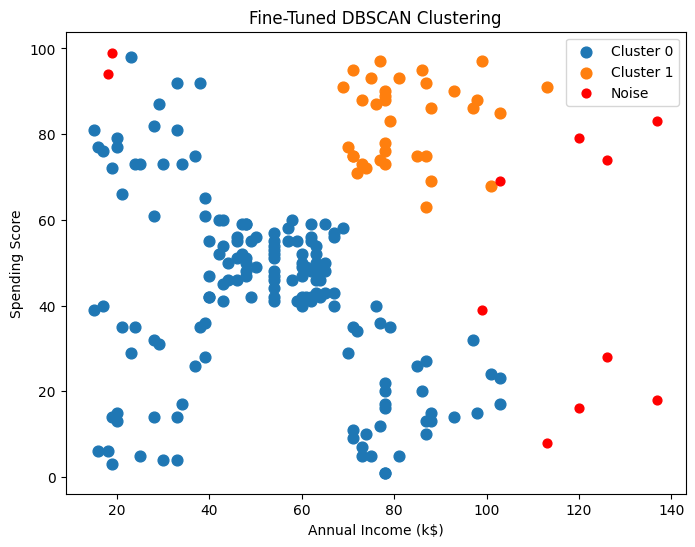

In [28]:
plt.figure(figsize=(8,6))

for cluster in set(clusters_tuned):
    if cluster == -1:
        plt.scatter(
            X.iloc[clusters_tuned == cluster, 0],
            X.iloc[clusters_tuned == cluster, 1],
            c='red', label='Noise', s=40
        )
    else:
        plt.scatter(
            X.iloc[clusters_tuned == cluster, 0],
            X.iloc[clusters_tuned == cluster, 1],
            label=f'Cluster {cluster}', s=60
        )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Fine-Tuned DBSCAN Clustering")
plt.legend()
plt.show()